<a href="https://colab.research.google.com/github/jillianb2m/tcc-futebol-analise/blob/main/tcc_ml_futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Imports

In [127]:
!pip install pingouin > /dev/null

In [128]:
import pandas as pd
import traceback
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from matplotlib.patches import FancyBboxPatch
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
import pingouin as pg
import plotly.express as px

# 2. Configuração

In [129]:
CONFIG = {
    'POSICAO_ALVO': 'Meia Central',
    'MIN_JOGOS': 5,
    'DATASET_PATH': '/content/tcc-futebol-analise/datasets/processed/brasileirao_opta_final.csv',
    'N_CLUSTERS_MAX': 6,
    'N_CLUSTERS_INICIAL': 5,
    'N_CLUSTERS_FINAL': 6,
    'METODO_LINKAGE': 'complete' # 'average'
}

mapa_variaveis = {
    'minutesPlayed': 'Minutos Jogados',
    'totalPass': 'Total de passes',
    'accuratePass': 'Passes certos',
    'totalTackle': 'Desarmes',
    'keyPass': 'Passes-chave',
    'rating': 'Rating',
    'goalAssist': 'Assistências',
    'totalShots': 'Finalizações',
    'goals': 'Gols',
    'interceptionWon': 'Interceptações',
    'Avg_X': 'Posição Horizontal',
    'Avg_Y': 'Posição Vertical'
}

texto_legenda = (
                    "Horizontal (Posição X):\n"
                    "• 0 = Lado Esquerdo\n"
                    "• 50 = Centro do Campo\n"
                    "• 100 = Lado Direito\n\n"
                    "Vertical (Posição Y):\n"
                    "• 0 = Linha de Ataque\n"
                    "• 50 = Linha do Meio Campo\n"
                    "• 100 = Linha de Defesa\n\n"
                    "Exemplos:\n"
                    "• Goleiro: (50, 90)\n"
                    "• Zagueiro: (50, 75)\n"
                    "• Volante: (50, 60)\n"
                    "• Meia: (50, 40)\n"
                    "• Atacante: (50, 20)"
                )

regras_col_agregacao = {
    'rating': 'mean',
    'minutesPlayed': 'sum',
    'totalShots': 'mean',
    'onTargetScoringAttempt': 'mean',
    'bigChanceCreated': 'mean',
    'expectedGoals': 'mean',
    'goals': 'sum',
    'goalAssist': 'sum',
    'totalPass': 'mean',
    'accuratePass': 'mean',
    'keyPass': 'mean',
    'touches': 'mean',
    'possessionLostCtrl': 'mean',
    'totalTackle': 'mean',
    'interceptionWon': 'mean',
    'ballRecovery': 'mean',
    'aerialWon': 'mean',
    'Avg_X': 'mean',
    'Avg_Y': 'mean'
}

# 3. Github

## 3.1. Clone

In [130]:
%run "/content/drive/MyDrive/Colab Notebooks/tcc-clone-repo.py"

<Figure size 640x480 with 0 Axes>

## 3.2. Commit

In [131]:
#%run "/content/drive/MyDrive/Colab Notebooks/tcc-commit-github.py"

# 4. Coleta e tratamento dos dados

In [132]:
# %run "/content/tcc-futebol-analise/src/scripts/preparar_base.py"

# 5. Clustering

## 5.1. Classe Clustering

### 5.1.1. Inicialização e gerar dataset base

In [133]:
class ClusterBrasileirao:
  def __init__(self, dataset_path):
    self.dataframe = pd.read_csv(dataset_path)
    self.dados_cluster = None
    self.variaveis_metricas = None
    self.dados_padronizados = None
    self.scaler = None

  def gerar_base(self, posicao_alvo=None, min_jogos=5):
    if posicao_alvo:
      df_filtro_alvo = self.dataframe[self.dataframe['Posicao_Real'] == posicao_alvo]
    else:
      df_filtro_alvo = self.dataframe.copy()

    colunas_existentes = [col for col in regras_col_agregacao.keys() if col in df_filtro_alvo.columns]
    agregacoes_filtradas = {k: v for k, v in regras_col_agregacao.items() if k in colunas_existentes}

    df_agregado_alvo = df_filtro_alvo.groupby(['Jogador', 'Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()

    df_alvo = df_agregado_alvo[df_agregado_alvo['minutesPlayed'] >= min_jogos * 90].copy()

    variaveis_esperadas = [
                            'rating', 'minutesPlayed',
                            'totalPass', 'onTargetScoringAttempt',
                            'bigChanceCreated', 'expectedGoals',
                            'accuratePass', 'touches',
                            'possessionLostCtrl', 'ballRecovery',
                            'totalShots', 'goals',
                            'totalTackle', 'interceptionWon',
                            'keyPass', 'goalAssist', 'aerialWon',
                            'Avg_X', 'Avg_Y'
                          ]

    v_metricas = [v for v in variaveis_esperadas if v in df_alvo.columns]

    self.dados_cluster = df_alvo[['Jogador', 'Time', 'Posicao_Real'] + v_metricas].copy()

    self.variaveis_metricas = v_metricas
    dados_metricos = self.dados_cluster[v_metricas].copy()

    return dados_metricos

### 5.1.2. Análise Exploratória

In [146]:
def explorar_variaveis_dataframe(self):
    print("********* Análise Exploratória *********")

    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)

    print(self.dados_cluster[self.variaveis_metricas].describe().loc[['mean', 'std', 'min', 'max']].T.round(2))
    print("\n")

    fig, axes = plt.subplots(3, 3, figsize=(24, 16))
    fig.suptitle('Distribuição das Variáveis de Desempenho', fontsize=18)

    if 'minutesPlayed' in self.variaveis_metricas:
        dados_melt_1 = pd.melt(self.dados_cluster[['minutesPlayed']])
        dados_melt_1['variable'] = dados_melt_1['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_1, ax=axes[0,0], palette='viridis', legend=False)
        axes[0,0].set_title('Minutos Jogados', fontsize=14)
        axes[0,0].set_ylabel('Minutos', fontsize=12)
        axes[0,0].set_xlabel('', fontsize=12)

    v_nivel_altissimo = ['totalPass', 'accuratePass']
    v_disponiveis_altissimo = [v for v in v_nivel_altissimo if v in self.variaveis_metricas]
    if v_disponiveis_altissimo:
        dados_melt_2 = pd.melt(self.dados_cluster[v_disponiveis_altissimo])
        dados_melt_2['variable'] = dados_melt_2['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_2, ax=axes[0,1], palette='viridis', legend=False)
        axes[0,1].set_title('Passes', fontsize=14)
        axes[0,1].set_ylabel('Valores por Jogo (20-60)', fontsize=12)
        axes[0,1].set_xlabel('', fontsize=12)
        axes[0,1].tick_params(axis='x', rotation=45)

    v_nivel_medio = ['totalTackle', 'keyPass']
    v_disponiveis_medio = [v for v in v_nivel_medio if v in self.variaveis_metricas]
    if v_disponiveis_medio:
        dados_melt_3 = pd.melt(self.dados_cluster[v_disponiveis_medio])
        dados_melt_3['variable'] = dados_melt_3['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_3, ax=axes[0,2], palette='viridis', legend=False)
        axes[0,2].set_title('Desarmes e Assistência (não gol)', fontsize=14)
        axes[0,2].set_ylabel('Valores por Jogo (0-8)', fontsize=12)
        axes[0,2].set_xlabel('', fontsize=12)
        axes[0,2].tick_params(axis='x', rotation=45)

    if 'rating' in self.variaveis_metricas:
        dados_melt_4 = pd.melt(self.dados_cluster[['rating']])
        dados_melt_4['variable'] = dados_melt_4['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_4, ax=axes[1,0], palette='viridis', legend=False)
        axes[1,0].set_title('Rating (Desempenho)', fontsize=14)
        axes[1,0].set_ylabel('Rating (6-8)', fontsize=12)
        axes[1,0].set_xlabel('', fontsize=12)

    v_assist_shots = ['goalAssist', 'totalShots']
    v_disponiveis_assist = [v for v in v_assist_shots if v in self.variaveis_metricas]
    if v_disponiveis_assist:
        dados_melt_5 = pd.melt(self.dados_cluster[v_disponiveis_assist])
        dados_melt_5['variable'] = dados_melt_5['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_5, ax=axes[1,1], palette='viridis', legend=False)
        axes[1,1].set_title('Assistências e Finalizações', fontsize=14)
        axes[1,1].set_ylabel('Valores por Jogo (0-5)', fontsize=12)
        axes[1,1].set_xlabel('', fontsize=12)
        axes[1,1].tick_params(axis='x', rotation=45)

    if 'goals' in self.variaveis_metricas:
        dados_melt_6 = pd.melt(self.dados_cluster[['goals']])
        dados_melt_6['variable'] = dados_melt_6['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_6, ax=axes[1,2], palette='viridis', legend=False)
        axes[1,2].set_title('Gols', fontsize=14)
        axes[1,2].set_ylabel('Gols por Jogo (0-20)', fontsize=12)
        axes[1,2].set_xlabel('', fontsize=12)

    if 'interceptionWon' in self.variaveis_metricas:
        dados_melt_7 = pd.melt(self.dados_cluster[['interceptionWon']])
        dados_melt_7['variable'] = dados_melt_7['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_7, ax=axes[2,0], palette='viridis', legend=False)
        axes[2,0].set_title('Interceptações', fontsize=14)
        axes[2,0].set_ylabel('Interceptações por Jogo (0-5)', fontsize=12)
        axes[2,0].set_xlabel('', fontsize=12)

    v_posicao = ['Avg_X', 'Avg_Y']
    v_disponiveis_posicao = [v for v in v_posicao if v in self.variaveis_metricas]
    if v_disponiveis_posicao:
        dados_melt_8 = pd.melt(self.dados_cluster[v_disponiveis_posicao])
        dados_melt_8['variable'] = dados_melt_8['variable'].replace(mapa_variaveis)
        sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt_8, ax=axes[2,1], palette='viridis', legend=False)
        axes[2,1].set_title('Posicionamento em Campo', fontsize=14)
        axes[2,1].set_ylabel('Coordenadas (0-100)', fontsize=12)
        axes[2,1].set_xlabel('', fontsize=12)

    axes[2,2].axis('off')
    axes[2,2].set_title('Legenda - Posicionamento em Campo', fontsize=14)

    rect = FancyBboxPatch((0.1, 0.15), 0.8, 0.7,
                          transform=axes[2,2].transAxes,
                          facecolor='lightblue', alpha=0.9,
                          edgecolor='navy', linewidth=2.0,
                          boxstyle='round,pad=0.5')
    axes[2,2].add_patch(rect)

    axes[2,2].text(0.15, 0.50, texto_legenda, transform=axes[2,2].transAxes,
                  fontsize=14, ha='left', va='center')

    plt.tight_layout()
    plt.savefig('boxplot_variaveis_melhorado.png', dpi=300, bbox_inches='tight')
    plt.show()

ClusterBrasileirao.explorar_variaveis_dataframe = explorar_variaveis_dataframe

### 5.1.3. Padronização dos Dados (ZScore ou StandardScaler)

In [135]:
def padronizar_dados(self, metodo='zscore'):

    dados_metricos = self.dados_cluster[self.variaveis_metricas].copy()

    if metodo == 'zscore':
        self.dados_padronizados = dados_metricos.apply(zscore, ddof=1)
        print("Padronização Z-Score aplicada")
    else:
        self.scaler = StandardScaler()
        self.dados_padronizados = pd.DataFrame(self.scaler.fit_transform(dados_metricos),
                                               columns=dados_metricos.columns,
                                               index=dados_metricos.index
                                              )
        print("Padronização StandardScaler aplicada")

    #print("\nMédias após padronização (devem ser ~0):")
    #print(self.dados_padronizados.mean())
    #print("\nDesvios padrão após padronização (devem ser ~1):")
    #print(self.dados_padronizados.std())

    return self.dados_padronizados

ClusterBrasileirao.padronizar_dados = padronizar_dados

### 5.1.4. Método Elbow

In [136]:
def analisar_elbow(self, max_clusters=8, random_state=100):

    elbow = []
    K = range(1, max_clusters + 1)

    for k in K:
      kmeans_elbow = KMeans(n_clusters=k, init='random',
                            random_state=random_state
                            ).fit(self.dados_padronizados)

      elbow.append(kmeans_elbow.inertia_)

    plt.figure(figsize=(12, 8), dpi=600)
    plt.plot(K, elbow, marker='o', linewidth=2, markersize=8)
    plt.xlabel('Nº Clusters', fontsize=16)
    plt.xticks(range(1, max_clusters + 1))
    plt.ylabel('WCSS', fontsize=16)
    plt.title('Método de Elbow', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('metodo_elbow.png', dpi=300, bbox_inches='tight')
    plt.show()

    quedas = []
    for i in range(1, len(elbow)):
      queda_percentual = ((elbow[i-1] - elbow[i]) / elbow[i-1]) * 100
      quedas.append(queda_percentual)

    if quedas:
      cotovelo_sugerido = quedas.index(max(quedas)) + 2
      print(f"Nº sugerido de clusters (cotovelo): {cotovelo_sugerido}")
      return cotovelo_sugerido

    return 3

ClusterBrasileirao.analisar_elbow = analisar_elbow

### 5.1.5. Clustering Hierárquico

In [137]:
def aplicar_hierarquico(self, n_clusters=3, metodo_linkage='average', metrica_distancia='euclidean'):

      print(f"\n********** Algoritmo Hierárquico ({metodo_linkage} linkage) **********")

      plt.figure(figsize=(16, 8), dpi=600)
      linkage_matrix = sch.linkage(self.dados_padronizados, method=metodo_linkage, metric=metrica_distancia)

      labels_jogadores = [f"{jog}"[:15] for jog in self.dados_cluster['Jogador'].values]
      dendrogram = sch.dendrogram(linkage_matrix, labels=labels_jogadores, color_threshold=6)

      plt.title(f'Dendrograma - {metodo_linkage.title()} Linkage', fontsize=16)
      plt.xlabel('Jogadores', fontsize=16)
      plt.ylabel(f'Distância {metrica_distancia.title()}', fontsize=16)
      plt.axhline(y=6, color='red', linestyle='--')
      plt.xticks(rotation=90)
      plt.tight_layout()
      #plt.savefig(f'dendrograma_{metodo_linkage}.png', dpi=300, bbox_inches='tight')
      #plt.show()

      cluster_hierarquico = AgglomerativeClustering(n_clusters=n_clusters,
                                                    metric=metrica_distancia,
                                                    linkage=metodo_linkage
                                                    )

      indicadores_cluster = cluster_hierarquico.fit_predict(self.dados_padronizados)
      self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = indicadores_cluster
      self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'].astype('category')

      coeficientes = [y[1] for y in dendrogram['dcoord']]
      print(f"Coeficientes de aglomeração ({metodo_linkage}): {coeficientes[:5]}...")

      print(f"\nDistribuição dos clusters ({metodo_linkage}):")
      for i in range(n_clusters):
          count = (indicadores_cluster == i).sum()
          percent = (count / len(indicadores_cluster)) * 100
          print(f"Cluster {i}: {count} jogadores ({percent:.1f}%)")

      return indicadores_cluster

ClusterBrasileirao.aplicar_hierarquico = aplicar_hierarquico

### 5.1.6. Clustering K-Means

In [138]:
def aplicar_kmeans(self, n_clusters=3, init_method='random', random_state=100):
      print(f"\n********** Algoritmo K-MEANS (k={n_clusters}) **********")

      kmeans = KMeans(n_clusters=n_clusters,
                      init=init_method,
                      random_state=random_state
                      ).fit(self.dados_padronizados)

      kmeans_clusters = kmeans.labels_
      self.dados_cluster['cluster_kmeans'] = kmeans_clusters
      self.dados_cluster['cluster_kmeans'] = self.dados_cluster['cluster_kmeans'].astype('category')

      centroides_originais = self.scaler.inverse_transform(kmeans.cluster_centers_)
      self.centroides = pd.DataFrame(centroides_originais)
      self.centroides.columns = self.variaveis_metricas
      self.centroides.index.name = 'cluster'

      print("\nCentroides dos clusters:")
      print(self.centroides.round(3))

      if len(self.variaveis_metricas) >= 2:
          plt.figure(figsize=(10, 8), dpi=600)

          var1, var2 = self.variaveis_metricas[0], self.variaveis_metricas[1]

          sns.scatterplot(data=self.dados_cluster, x=var1, y=var2,
                          hue='cluster_kmeans', palette='viridis', s=100)

          centroides_plot = self.centroides[[var1, var2]].copy()

          sns.scatterplot(data=centroides_plot, x=var1, y=var2, c='red',
                          label='Centróides', marker="X", s=200)

          plt.title('Clusters e Centroides', fontsize=16)
          plt.xlabel(var1.replace('_', ' ').title(), fontsize=14)
          plt.ylabel(var2.replace('_', ' ').title(), fontsize=14)
          plt.legend()
          plt.grid(True, alpha=0.3)
          plt.tight_layout()
          plt.savefig('clusters_centroides.png', dpi=300, bbox_inches='tight')
          plt.show()

      return kmeans_clusters

ClusterBrasileirao.aplicar_kmeans = aplicar_kmeans

### 5.1.7. Variância ANOVA

In [139]:
def comparar_clusters_anova(self):
    print("\n=== ANÁLISE DE VARIÂNCIA (ANOVA) ===")

    print("Interpretação do output:")
    print("- cluster_kmeans MS: variabilidade entre grupos")
    print("- Within MS: variabilidade dentro dos grupos")
    print("- F: estatística de teste (MS entre / MS dentro)")
    print("- p-unc: p-valor da estatística F")
    print("- p-valor < 0.05: pelo menos um cluster apresenta média estatisticamente diferente")

    resultados_anova = {}

    # ANOVA para cada variável
    for variavel in self.variaveis_metricas:
        print(f"\n--- ANOVA para {variavel} ---")

        resultado = pg.anova(
            dv=variavel,
            between='cluster_kmeans',
            data=self.dados_cluster,
            detailed=True
        ).T

        print(resultado.round(4))

        # Extrair estatística F e p-valor
        if 'F' in resultado.index and 'p-unc' in resultado.index:
            f_stat = resultado.loc['F', 'cluster_kmeans']
            p_value = resultado.loc['p-unc', 'cluster_kmeans']

            resultados_anova[variavel] = {
                'F_stat': f_stat,
                'p_value': p_value,
                'significativo': p_value < 0.05
            }

            print(f"Estatística F: {f_stat:.3f}")
            print(f"P-valor: {p_value:.4f}")
            print(f"Significativo: {'Sim' if p_value < 0.05 else 'Não'}")

    # Identificar variável mais discriminante
    if resultados_anova:
        variaveis_significativas = [var for var, res in resultados_anova.items() if res['significativo']]

        if variaveis_significativas:
            # Variável com maior estatística F
            mais_discriminante = max(
                variaveis_significativas,
                key=lambda x: resultados_anova[x]['F_stat']
            )
            print(f"\nVariável mais discriminante: {mais_discriminante}")
            print(f"Estatística F: {resultados_anova[mais_discriminante]['F_stat']:.3f}")

    return resultados_anova

ClusterBrasileirao.comparar_clusters_anova = comparar_clusters_anova

### 5.1.8. Clusters no gráfico 3D

In [140]:
def gerar_clusters_3d(self):
    if len(self.variaveis_metricas) >= 3:
        print("\n=== VISUALIZAÇÃO 3D DOS CLUSTERS ===")

        # Usar as 3 primeiras variáveis
        var1, var2, var3 = self.variaveis_metricas[:3]

        fig = px.scatter_3d(
            self.dados_cluster,
            x=var1,
            y=var2,
            z=var3,
            color='cluster_kmeans',
            text=self.dados_cluster['Jogador'],
            title=f'Clusters 3D: {var1} vs {var2} vs {var3}'
        )

        fig.write_html('clusters_3d.html')
        print("Visualização 3D salva como 'clusters_3d.html'")

ClusterBrasileirao.gerar_clusters_3d = gerar_clusters_3d

### 5.1.9. Interpretar perfil dos clusters (jogadores)

In [141]:
def interpretar_perfis_clusters(self):
    print("\n=== ANÁLISE DE PERFIS DOS CLUSTERS ===")

    n_clusters = self.dados_cluster['cluster_kmeans'].nunique()

    for cluster_id in sorted(self.dados_cluster['cluster_kmeans'].unique()):
        print(f"\n--- CLUSTER {cluster_id} ---")

        dados_cluster = self.dados_cluster[self.dados_cluster['cluster_kmeans'] == cluster_id]

        print(f"Tamanho: {len(dados_cluster)} jogadores")
        print(f"Percentual: {(len(dados_cluster)/len(self.dados_cluster)*100):.1f}%")

        # Top 5 jogadores do cluster
        top_jogadores = dados_cluster.nlargest(5, 'rating')[['Jogador', 'Time', 'Posicao_Real', 'rating']]
        print("\nTop 5 jogadores (rating):")
        for _, row in top_jogadores.iterrows():
            print(f"  {row['Jogador']} ({row['Posicao_Real']}) - {row['Time']}: {row['rating']:.1f}")

        # Estatísticas das variáveis principais
        print("\nCaracterísticas médias:")
        for var in ['rating', 'minutesPlayed', 'totalPass', 'totalShots', 'goals']:
            if var in dados_cluster.columns:
                media = dados_cluster[var].mean()
                print(f"  {var}: {media:.2f}")

        # Distribuição de posições
        dist_posicoes = dados_cluster['Posicao_Real'].value_counts()
        print(f"\nPosições principais:")
        for posicao, count in dist_posicoes.head(3).items():
            percent = (count / len(dados_cluster)) * 100
            print(f"  {posicao}: {count} ({percent:.1f}%)")

ClusterBrasileirao.interpretar_perfis_clusters = interpretar_perfis_clusters

### 5.1.10. Identificar reforços

In [142]:
def identificar_reforcos_elenco(self):
    print("\n=== IDENTIFICAÇÃO DE REFORÇOS POTENCIAIS ===")

    rating_por_cluster = self.dados_cluster.groupby(
        'cluster_kmeans', observed=False
    )['rating'].mean()

    cluster_melhor = rating_por_cluster.idxmax()

    print(f"Cluster com melhor rating médio: {cluster_melhor} (rating: {rating_por_cluster.max():.2f})")

    dados_cluster_alvo = self.dados_cluster.loc[
        self.dados_cluster['cluster_kmeans'] == cluster_melhor
    ].copy()

    metricas_desempenho = ['totalPass', 'totalShots', 'goals', 'totalTackle', 'interceptionWon', 'keyPass']
    metricas_disponiveis = [m for m in metricas_desempenho if m in dados_cluster_alvo.columns]

    if metricas_disponiveis:
        dados_cluster_alvo.loc[:, 'score_desempenho'] = (
            dados_cluster_alvo[metricas_disponiveis].sum(axis=1)
        )

        threshold_desempenho = dados_cluster_alvo['score_desempenho'].quantile(0.75)
        threshold_rating = dados_cluster_alvo['rating'].quantile(0.5)

        reforcos_potenciais = dados_cluster_alvo[
            (dados_cluster_alvo['score_desempenho'] >= threshold_desempenho) &
            (dados_cluster_alvo['rating'] <= threshold_rating)
        ].sort_values('score_desempenho', ascending=False)

        if len(reforcos_potenciais) <= 1:
            reforcos_potenciais = dados_cluster_alvo.sort_values(
                'score_desempenho', ascending=False
            )

        print("\nTop 10 potenciais reforços:")
        for _, row in reforcos_potenciais.head(10).iterrows():
            print(f"{row['Jogador']} ({row['Posicao_Real']}) - {row['Time']}")
            print(f"  Rating: {row['rating']:.1f} | Score: {row['score_desempenho']:.0f}")
            print()

    return reforcos_potenciais if 'reforcos_potenciais' in locals() else None

ClusterBrasileirao.identificar_reforcos_elenco = identificar_reforcos_elenco

## 5.2. Função main

********* Análise Exploratória *********
                           mean     std     min      max
rating                     6.94    0.20    6.44     7.52
minutesPlayed           1206.23  892.60  450.00  4838.00
totalPass                 25.13   12.60    7.31    78.29
onTargetScoringAttempt     0.50    0.27    0.00     1.33
bigChanceCreated           0.14    0.12    0.00     0.58
expectedGoals              0.15    0.10    0.01     0.51
accuratePass              20.79   11.83    4.50    71.71
touches                   37.42   13.93   13.50    85.86
possessionLostCtrl         8.86    2.74    3.11    18.74
ballRecovery               2.82    1.13    0.67     6.42
totalShots                 1.39    0.55    0.38     3.00
goals                      3.10    4.06    0.00    23.00
totalTackle                0.91    0.51    0.08     2.67
interceptionWon            0.36    0.29    0.00     1.62
keyPass                    1.04    0.57    0.08     3.00
goalAssist                 1.80    2.39    0.00

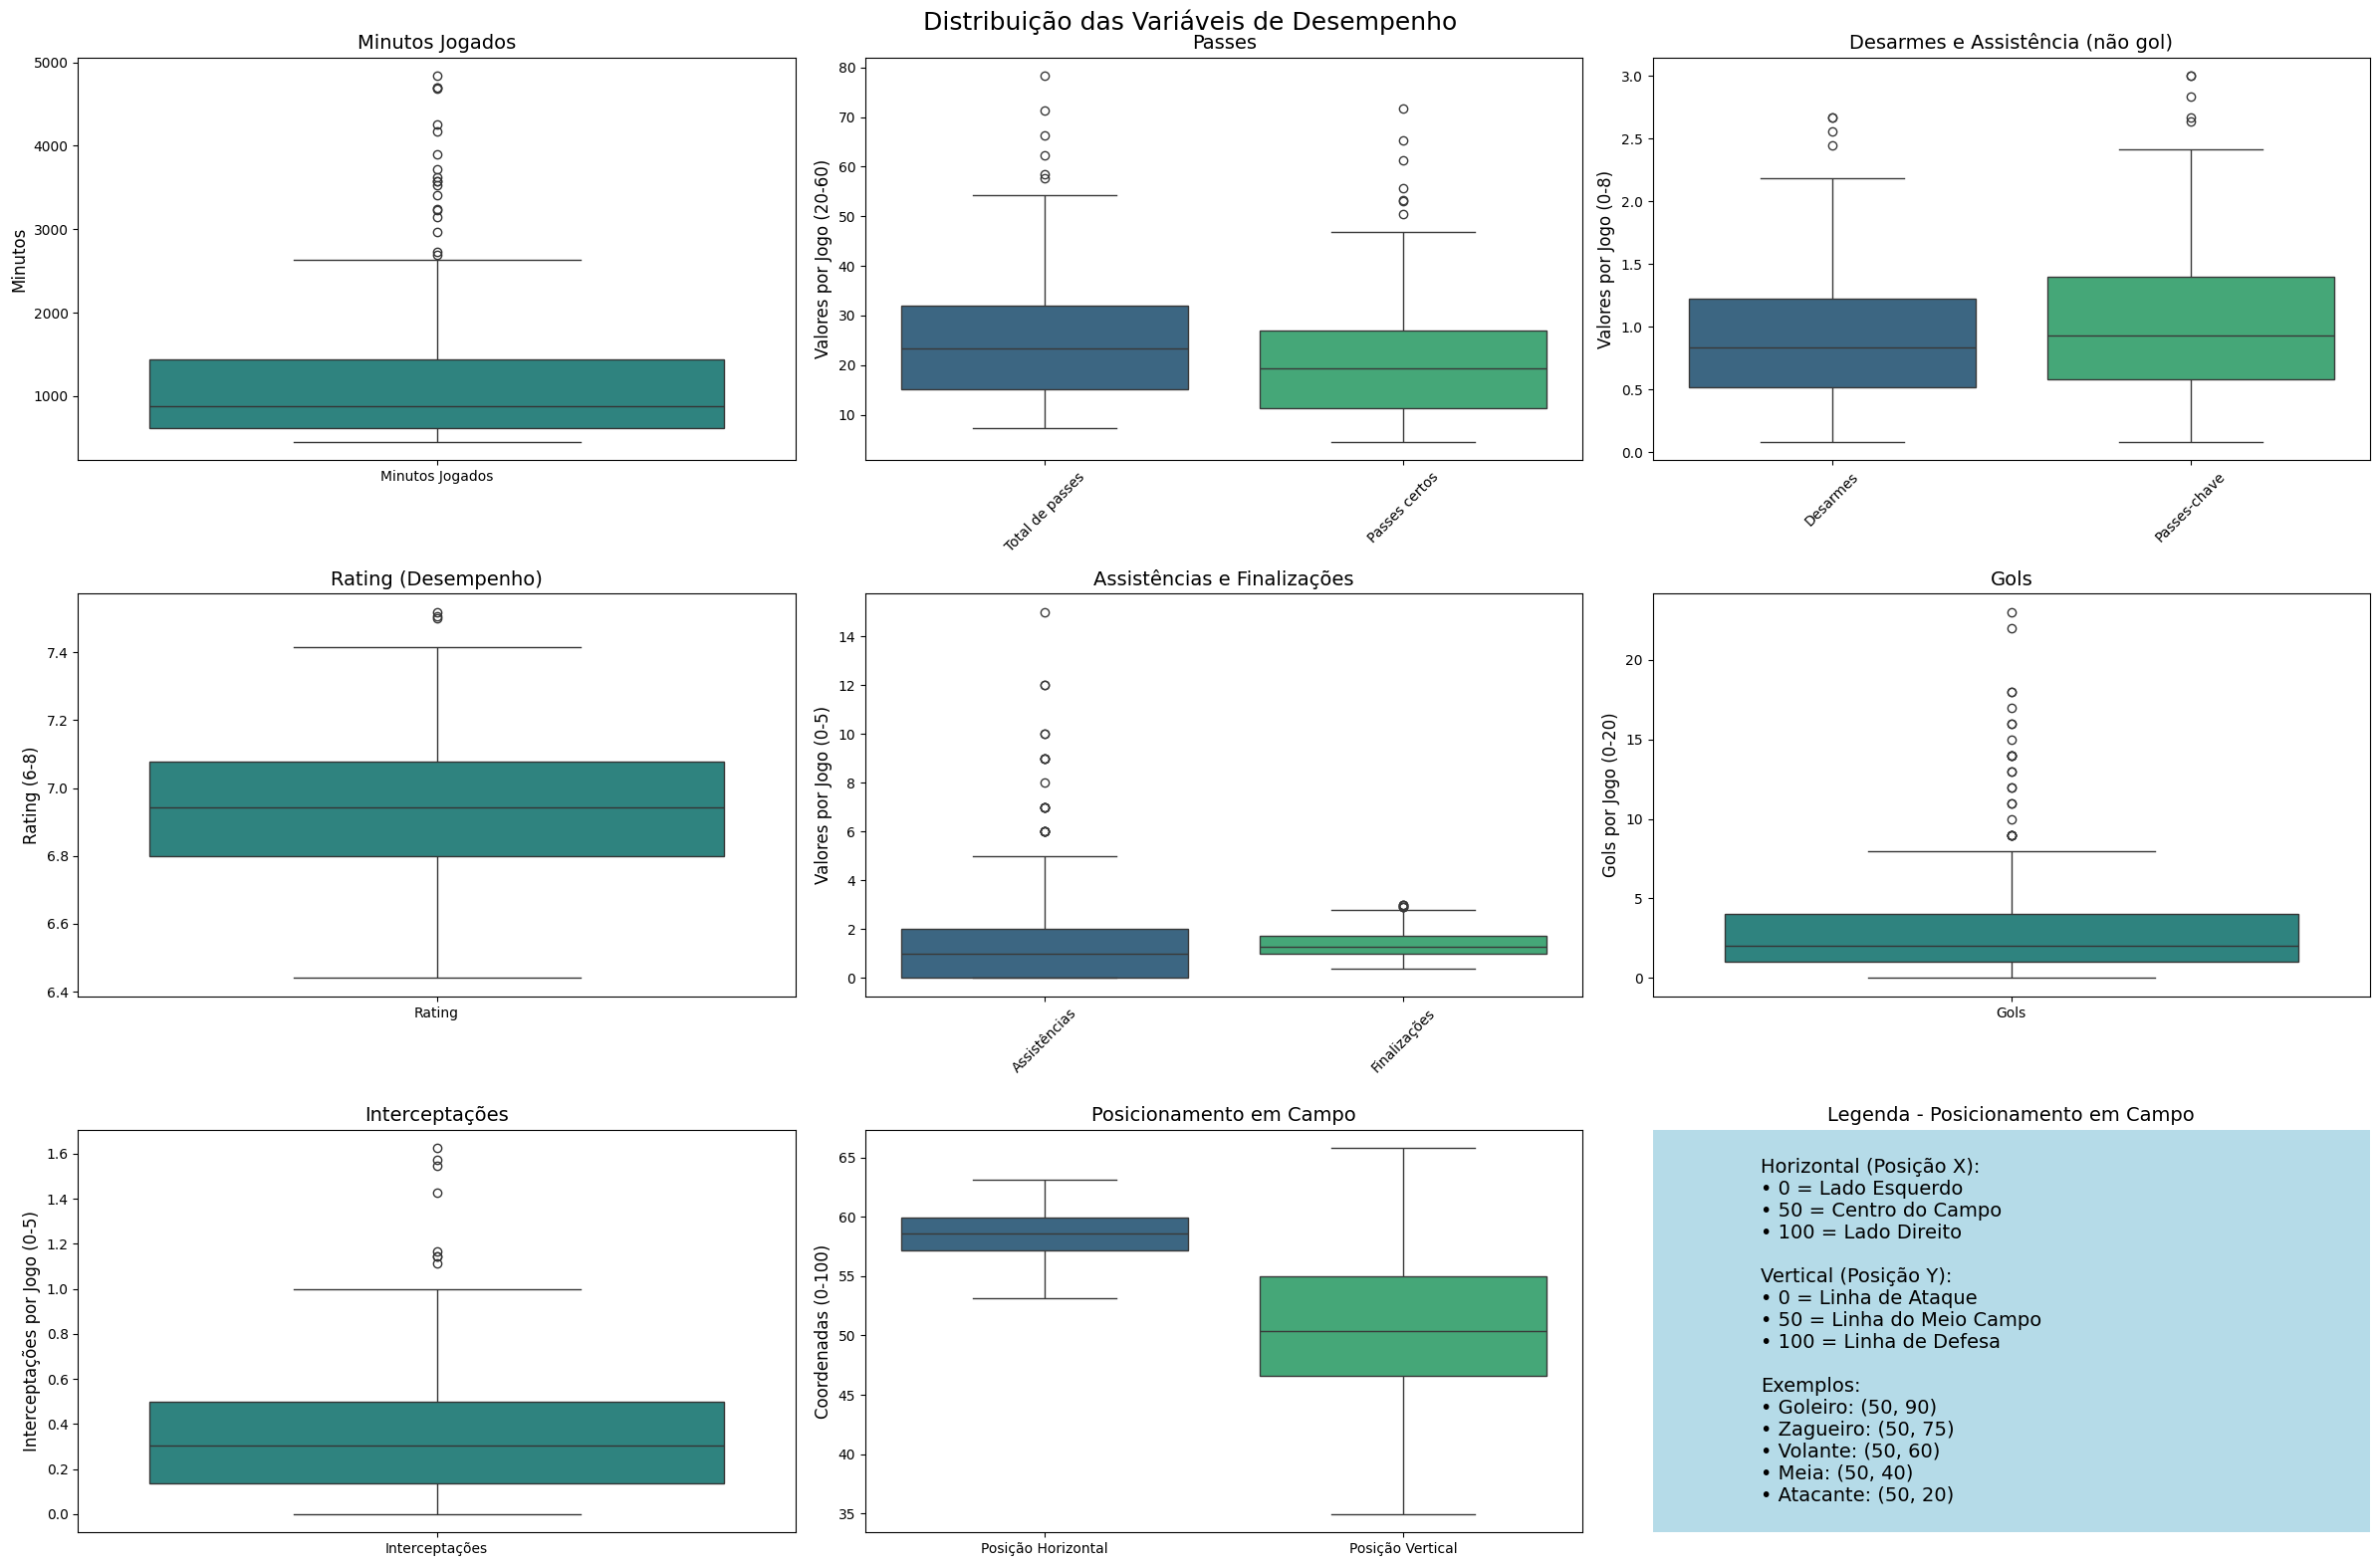

In [147]:
# Cell 8: Função Principal
def main(pos_alvo=CONFIG['POSICAO_ALVO'], min_jogos=CONFIG['MIN_JOGOS']):

  resultado_final = ClusterBrasileirao(CONFIG['DATASET_PATH'])

  try:
    dados_metricos_result = resultado_final.gerar_base(pos_alvo, min_jogos)
  except Exception as e:
    print('Erro ao gerar dados métricos: ' + traceback.format_exc())

  resultado_final.explorar_variaveis_dataframe()
"""
  dados_padronizados = resultado_final.padronizar_dados(metodo='sklearn')

  #k_ideal = resultado_final.analisar_elbow(max_clusters=CONFIG['N_CLUSTERS_MAX'])

  for i in range(CONFIG['N_CLUSTERS_INICIAL'], CONFIG['N_CLUSTERS_FINAL']):
    resultado_final.aplicar_hierarquico(n_clusters=i, metodo_linkage=CONFIG['METODO_LINKAGE'])

    resultado_final.aplicar_kmeans(n_clusters=i)

  resultados_anova = resultado_final.comparar_clusters_anova()

  resultado_final.gerar_clusters_3d()
  resultado_final.interpretar_perfis_clusters()
  resultado_final.identificar_reforcos_elenco()

  return dados_metricos_result
"""
if __name__ == "__main__":
    dados_metricos = main()